# Assignment 1 — Linear Regression

predicting house prices using basic libs..

## 1. Loading the data

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams['figure.figsize'] = (10, 6)

first few rows:
plt.rcParams['font.size'] = 12
sns.set_style("whitegrid")

In [ ]:
# read the csv
df = pd.read_csv("data (3).csv")

print("shape:", df.shape)
print("\nfirst few rows:")
df.head()

shape: (500, 12)

first few rows:


,ID,Square_Feet,Num_Bedrooms,Num_Bathrooms,Num_Floors,Year_Built,Has_Garden,Has_Pool,Garage_Size,Location_Score,Distance_to_Center,Price
0,1,143.635030,1.0,3.0,3.0,1967.0,1.0,1.0,48.0,8.297631,5.935734,6021
1,2,287.678577,1.0,2.0,1.0,1949.0,0.0,1.0,37.0,6.061466,10.827392,5914
2,3,232.998485,1.0,3.0,2.0,1923.0,1.0,0.0,14.0,2.911442,6.904599,4645
3,4,199.664621,5.0,2.0,2.0,1918.0,0.0,0.0,17.0,2.070949,8.284019,5831
4,5,89.004660,4.0,3.0,3.0,1999.0,1.0,0.0,34.0,1.523278,14.648277,6199


In [ ]:
# cols and their types
print("cols and dtypes:\n")
print(df.dtypes)

cols and dtypes:

ID                      int64
Square_Feet           float64
Num_Bedrooms          float64
Num_Bathrooms         float64
Num_Floors            float64
Year_Built            float64
Has_Garden            float64
Has_Pool              float64
Garage_Size           float64
Location_Score        float64
Distance_to_Center    float64
Price                   int64
dtype: object


In [ ]:
# quick stats
print("\nbasic stats:\n")
df.describe()


basic stats:



,ID,Square_Feet,Num_Bedrooms,Num_Bathrooms,Num_Floors,Year_Built,Has_Garden,Has_Pool,Garage_Size,Location_Score,Distance_to_Center,Price
count,500.000000,495.000000,494.000000,499.000000,497.000000,498.000000,494.000000,499.000000,496.000000,499.000000,499.000000,500.000000
mean,250.500000,174.568172,2.955466,1.977956,1.963783,1957.734940,0.536437,0.490982,30.225806,5.156770,10.482469,5822.106000
std,144.481833,74.952343,1.441925,0.819880,0.802401,35.470026,0.499176,0.500420,11.536040,2.851229,5.586431,1222.726482
min,1.000000,51.265396,1.000000,1.000000,1.000000,1900.000000,0.000000,0.000000,10.000000,0.004428,0.062818,2769.000000
25%,125.750000,109.649929,2.000000,1.000000,1.000000,1926.250000,0.000000,0.000000,20.000000,2.758926,6.076542,5031.000000
50%,250.500000,178.023265,3.000000,2.000000,2.000000,1959.000000,1.000000,0.000000,30.000000,5.197043,10.911704,5747.500000
75%,375.250000,239.828895,4.000000,3.000000,3.000000,1988.000000,1.000000,1.000000,41.000000,7.726950,15.073287,6659.500000
max,500.000000,298.241199,5.000000,3.000000,3.000000,2022.000000,1.000000,1.000000,49.000000,9.995439,19.927966,9607.000000


In [ ]:
# check for missing vals
print("missing vals per col:\n")
mis = df.isnull().sum()
print(mis)
print(f"\ntotal missing: {mis.sum()}")

missing vals per col:

ID                    0
Square_Feet           5
Num_Bedrooms          6
Num_Bathrooms         1
Num_Floors            3
Year_Built            2
Has_Garden            6
Has_Pool              1
Garage_Size           4
Location_Score        1
Distance_to_Center    1
Price                 0
dtype: int64

total missing: 30


### Handling missing values

a few cols have some gaps. not too many though, so filling them with the median of each col.
median is better than mean here since it wont get thrown off by outliers.

In [ ]:
# drop id col, its just an identifier
df = df.drop(columns=['ID'])

# fill gaps with median
for c in df.columns:
    if df[c].isnull().sum() > 0:
        mv = df[c].median()
        print(f"filling {df[c].isnull().sum()} missing in '{c}' with median = {mv:.4f}")
        df[c] = df[c].fillna(mv)

print("\nmissing after fix:", df.isnull().sum().sum())

filling 5 missing in 'Square_Feet' with median = 178.0233
filling 6 missing in 'Num_Bedrooms' with median = 3.0000
filling 1 missing in 'Num_Bathrooms' with median = 2.0000
filling 3 missing in 'Num_Floors' with median = 2.0000
filling 2 missing in 'Year_Built' with median = 1959.0000
filling 6 missing in 'Has_Garden' with median = 1.0000
filling 1 missing in 'Has_Pool' with median = 0.0000
filling 4 missing in 'Garage_Size' with median = 30.0000
filling 1 missing in 'Location_Score' with median = 5.1970
filling 1 missing in 'Distance_to_Center' with median = 10.9117

missing after fix: 0


## 2. Exploratory data analysis

a look at the data

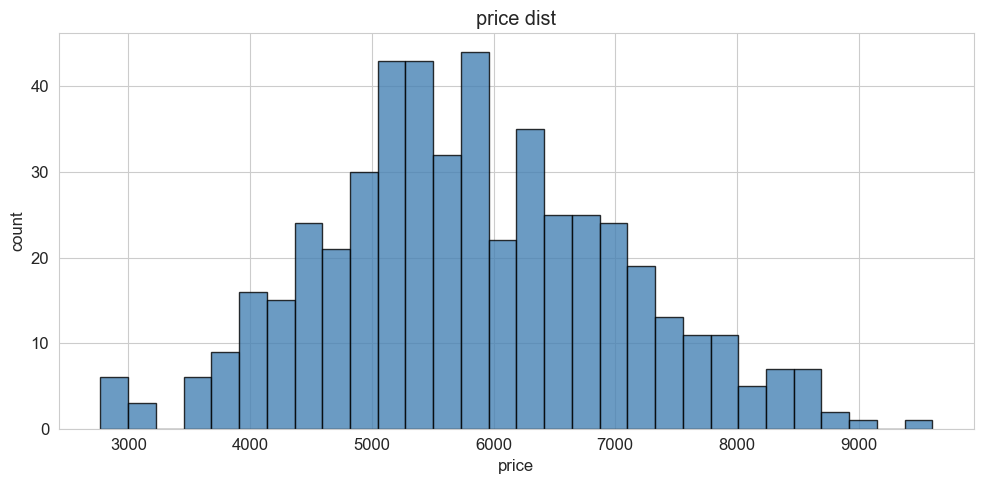

range: 2769 to 9607
mean: 5822.11
median: 5747.50


In [ ]:
# price dist
plt.figure(figsize=(10, 5))
plt.hist(df['Price'], bins=30, color='steelblue', edgecolor='black', alpha=0.8)
plt.title('price dist')
plt.xlabel('price')
plt.ylabel('count')
plt.tight_layout()
plt.show()

print(f"range: {df['Price'].min()} to {df['Price'].max()}")
print(f"mean: {df['Price'].mean():.2f}")
print(f"median: {df['Price'].median():.2f}")

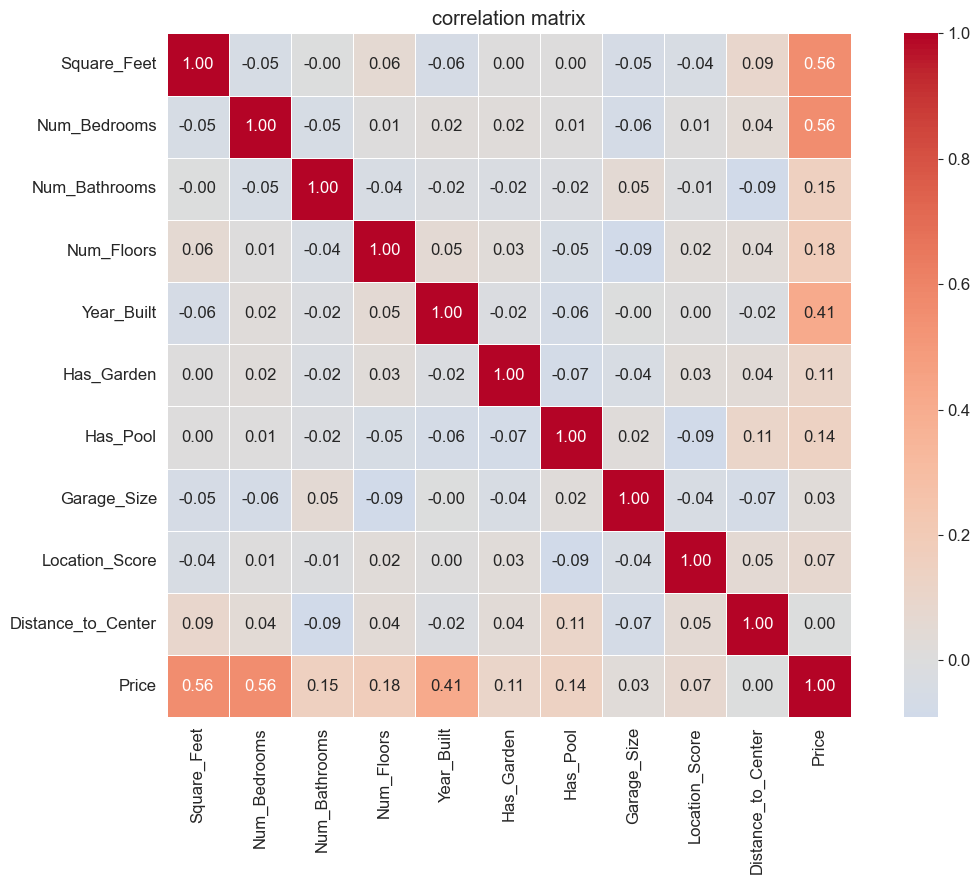

In [ ]:
# correlation heatmap
comx = df.corr()

plt.figure(figsize=(12, 9))
sns.heatmap(comx, annot=True, fmt=".2f", cmap='coolwarm', center=0,
            square=True, linewidths=0.5)
plt.title('correlation matrix')
plt.tight_layout()
plt.show()

In [ ]:
# how each feature correlates with price
pcorr = comx['Price'].drop('Price').sort_values(ascending=False)
print("correlation with price:\n")
print(pcorr.to_string())

correlation with price:

Num_Bedrooms          0.559928
Square_Feet           0.557677
Year_Built            0.411551
Num_Floors            0.177389
Num_Bathrooms         0.154428
Has_Pool              0.136531
Has_Garden            0.106860
Location_Score        0.074528
Garage_Size           0.026739
Distance_to_Center    0.001872


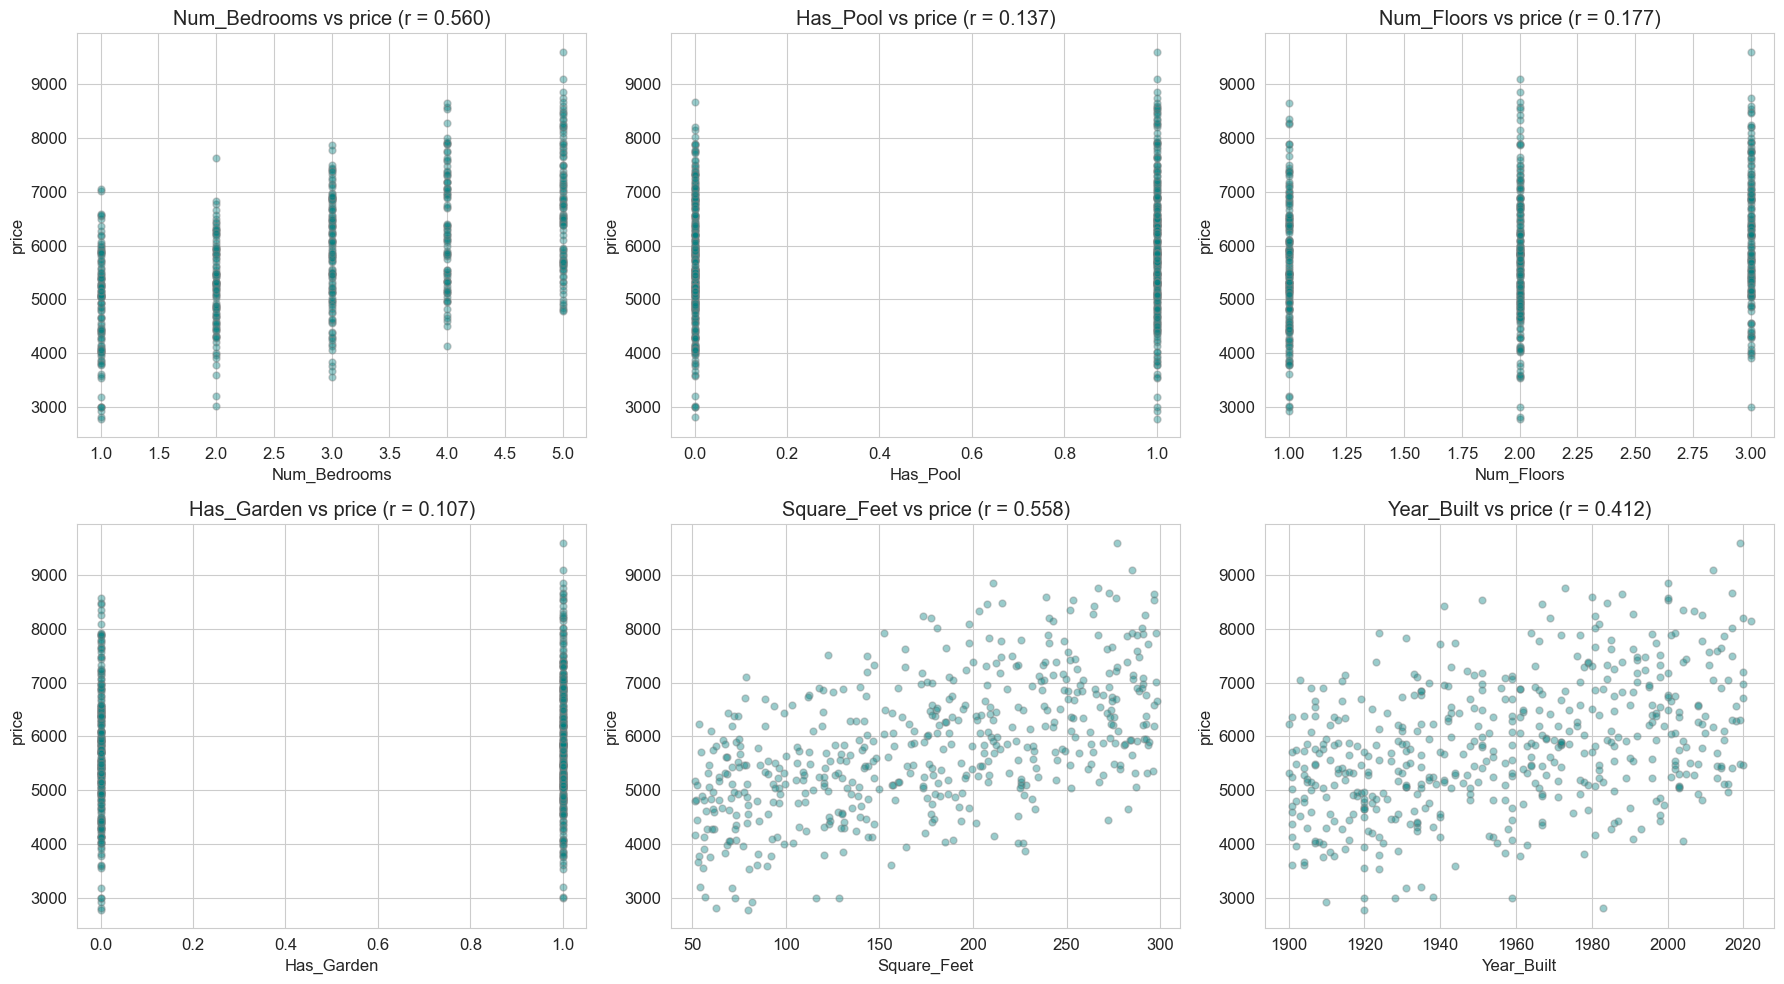

In [ ]:
# scatter plots for some interesting features
ftop = ['Num_Bedrooms', 'Has_Pool', 'Num_Floors', 'Has_Garden',
        'Square_Feet', 'Year_Built']

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, ft in enumerate(ftop):
    axes[i].scatter(df[ft], df['Price'], alpha=0.4, color='teal', edgecolors='gray', s=25)
    axes[i].set_xlabel(ft)
    axes[i].set_ylabel('price')
    axes[i].set_title(f'{ft} vs price (r = {comx.loc[ft, "Price"]:.3f})')

plt.tight_layout()
plt.show()

## 3. Linear regression — matrix method 

we minimize the sum of squared residuals. the closed form solution works out to:

$$\hat{\beta} = (X^T X)^{-1} X^T y$$

we prepend a col of ones to X for the intercept term, then just plug into the formula.

In [ ]:
# set up features and target
fcols = ['Square_Feet', 'Num_Bedrooms', 'Num_Bathrooms', 'Num_Floors',
         'Year_Built', 'Has_Garden', 'Has_Pool', 'Garage_Size',
         'Location_Score', 'Distance_to_Center']

xraw = df[fcols].values
y = df['Price'].values

n = xraw.shape[0]
p = xraw.shape[1]

print(f"n = {n}, p = {p}")

n = 500, p = 10


In [ ]:
# 80-20 train test split 
np.random.seed(42)
idx = np.arange(n)
np.random.shuffle(idx)

sp = int(0.8 * n)
tr_idx = idx[:sp]
te_idx = idx[sp:]

xtr_raw = xraw[tr_idx]
xte_raw = xraw[te_idx]
ytr = y[tr_idx]
yte = y[te_idx]

print(f"train: {xtr_raw.shape[0]}, test: {xte_raw.shape[0]}")

train: 400, test: 100


In [ ]:
# add intercept col (ones) to design matrix
xtr = np.hstack([np.ones((xtr_raw.shape[0], 1)), xtr_raw])
xte = np.hstack([np.ones((xte_raw.shape[0], 1)), xte_raw])

print(f"design matrix — train: {xtr.shape}, test: {xte.shape}")

design matrix — train: (400, 11), test: (100, 11)


In [ ]:
#  bhat = inv(X'X) * X'y

xtx = xtr.T @ xtr           # gram matrix
xtx_inv = np.linalg.inv(xtx)
xty = xtr.T @ ytr

bhat = xtx_inv @ xty        # the coeff

cnames = ['intercept'] + fcols
print("estimated coeff:\n")
for nm, cf in zip(cnames, bhat):
    print(f"  {nm:>22s}: {cf:>12.4f}")

estimated coeff:

               intercept:  -29479.1530
             Square_Feet:      10.1519
            Num_Bedrooms:     508.8051
           Num_Bathrooms:     277.0566
              Num_Floors:     220.3595
              Year_Built:      15.4905
              Has_Garden:     288.0328
                Has_Pool:     468.5180
             Garage_Size:      10.6214
          Location_Score:      43.2360
      Distance_to_Center:     -19.1732


### What the coefficients mean

each coeff is basically how much the price shifts per one unit increase in that feature,
holding everything else fixed. positive means price goes up, negative means it goes down.

## 4. Evaluating the model

In [ ]:
# predictions
ytr_hat = xtr @ bhat
yte_hat = xte @ bhat

In [ ]:

# residuals
res_tr = ytr - ytr_hat
res_te = yte - yte_hat

# rss = sum of squared residuals
rss_tr = np.sum(res_tr ** 2)
rss_te = np.sum(res_te ** 2)

# mse = rss / n
mse_tr = rss_tr / len(ytr)
mse_te = rss_te / len(yte)

# rmse for easier reading
rmse_tr = np.sqrt(mse_tr)
rmse_te = np.sqrt(mse_te)

# r-squared = 1 - rss/tss
tss_tr = np.sum((ytr - np.mean(ytr)) ** 2)
tss_te = np.sum((yte - np.mean(yte)) ** 2)

r2_tr = 1 - rss_tr / tss_tr
r2_te = 1 - rss_te / tss_te

print("=" * 55)
print("         model performance")
print("=" * 55)
print(f"{'metric':<25} {'train':>12} {'test':>12}")
print("-" * 55)
print(f"{'rss':<25} {rss_tr:>12.2f} {rss_te:>12.2f}")
print(f"{'mse':<25} {mse_tr:>12.2f} {mse_te:>12.2f}")
print(f"{'rmse':<25} {rmse_tr:>12.2f} {rmse_te:>12.2f}")
print(f"{'r-squared':<25} {r2_tr:>12.4f} {r2_te:>12.4f}")
print("=" * 55)

         model performance
metric                           train         test
-------------------------------------------------------
rss                        18691778.90   5678832.58
mse                           46729.45     56788.33
rmse                            216.17       238.30
r-squared                       0.9691       0.9592


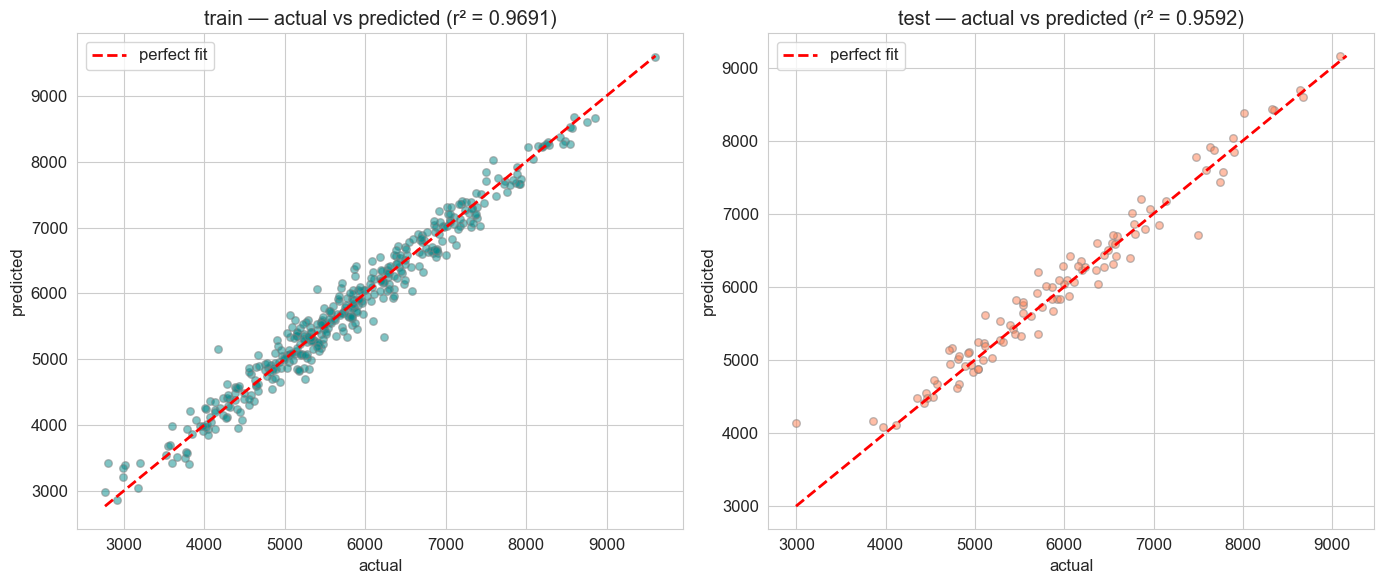

In [ ]:
# actual vs predicted
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].scatter(ytr, ytr_hat, alpha=0.5, color='darkcyan', edgecolors='gray', s=30)
lo = min(ytr.min(), ytr_hat.min())
hi = max(ytr.max(), ytr_hat.max())
axes[0].plot([lo, hi], [lo, hi], 'r--', lw=2, label='perfect fit')
axes[0].set_xlabel('actual')
axes[0].set_ylabel('predicted')
axes[0].set_title(f'train — actual vs predicted (r² = {r2_tr:.4f})')
axes[0].legend()

axes[1].scatter(yte, yte_hat, alpha=0.5, color='coral', edgecolors='gray', s=30)
lo = min(yte.min(), yte_hat.min())
hi = max(yte.max(), yte_hat.max())
axes[1].plot([lo, hi], [lo, hi], 'r--', lw=2, label='perfect fit')
axes[1].set_xlabel('actual')
axes[1].set_ylabel('predicted')
axes[1].set_title(f'test — actual vs predicted (r² = {r2_te:.4f})')
axes[1].legend()

plt.tight_layout()
plt.show()

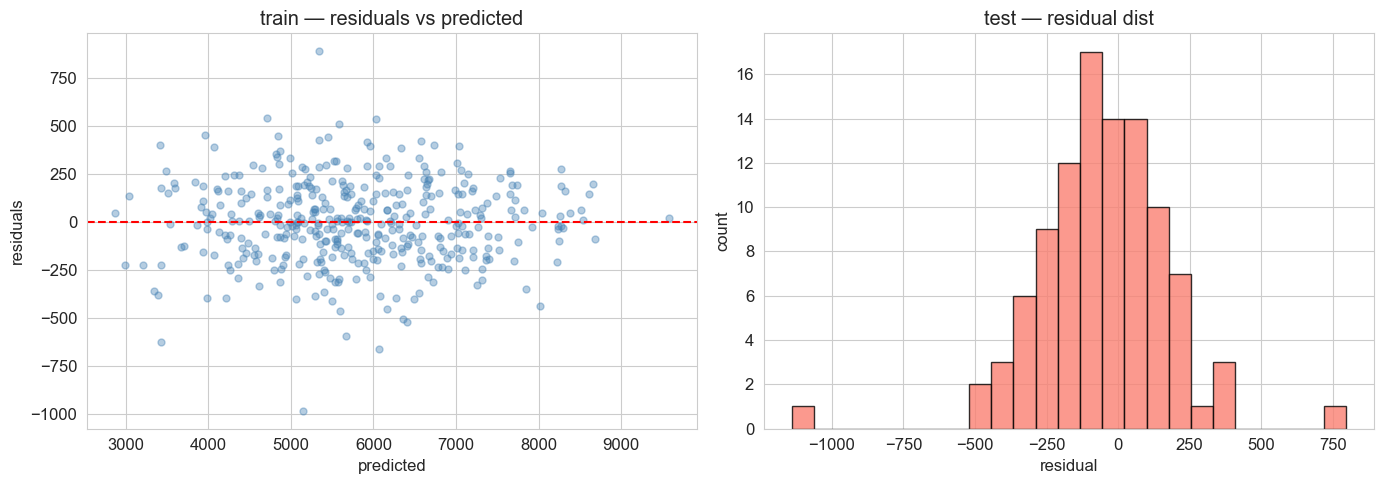

In [ ]:
# residual plots
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(ytr_hat, res_tr, alpha=0.4, color='steelblue', s=25)
axes[0].axhline(y=0, color='red', linestyle='--', lw=1.5)
axes[0].set_xlabel('predicted')
axes[0].set_ylabel('residuals')
axes[0].set_title('train — residuals vs predicted')

axes[1].hist(res_te, bins=25, color='salmon', edgecolor='black', alpha=0.8)
axes[1].set_xlabel('residual')
axes[1].set_ylabel('count')
axes[1].set_title('test — residual dist')

plt.tight_layout()
plt.show()

r-squared tells us how much of the variance in price our features explain. the residual plot
should kindof look random around zero since any pattern might mean we're missing something

---
## Bonus 1 — Standardisation

standardising = shifting each feature to mean 0, std 1:

$$z = \frac{x - \bar{x}}{\sigma}$$

after this, we can actually compare coeff sizes to see which features matter most.

In [ ]:
# compute stats from train only 
tr_mu = np.mean(xtr_raw, axis=0)
tr_sig = np.std(xtr_raw, axis=0)

# standardise
xtr_s = (xtr_raw - tr_mu) / tr_sig
xte_s = (xte_raw - tr_mu) / tr_sig

# add intercept
xtr_sf = np.hstack([np.ones((xtr_s.shape[0], 1)), xtr_s])
xte_sf = np.hstack([np.ones((xte_s.shape[0], 1)), xte_s])

print("after standardising:")
print(f"  train means (should be ~0): {np.mean(xtr_s, axis=0).round(6)}")
print(f"  train stds  (should be ~1): {np.std(xtr_s, axis=0).round(4)}")

after standardising:
  train means (should be ~0): [ 0.  0. -0.  0.  0. -0. -0. -0.  0. -0.]
  train stds  (should be ~1): [1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]


In [ ]:
# fit ols on standardised data
xtx_s = xtr_sf.T @ xtr_sf
xtx_inv_s = np.linalg.inv(xtx_s)
xty_s = xtr_sf.T @ ytr

bhat_s = xtx_inv_s @ xty_s

print("\nstandardised coeff:\n")
for nm, cf in zip(cnames, bhat_s):
    print(f"  {nm:>22s}: {cf:>12.4f}")


standardised coeff:

               intercept:    5788.7550
             Square_Feet:     756.1185
            Num_Bedrooms:     732.2983
           Num_Bathrooms:     225.4811
              Num_Floors:     178.6127
              Year_Built:     539.8321
              Has_Garden:     143.0609
                Has_Pool:     234.1858
             Garage_Size:     121.0052
          Location_Score:     120.5476
      Distance_to_Center:    -106.1125


In [ ]:
# metrics for standardised model
ytr_hat_s = xtr_sf @ bhat_s
yte_hat_s = xte_sf @ bhat_s

rss_tr_s = np.sum((ytr - ytr_hat_s) ** 2)
rss_te_s = np.sum((yte - yte_hat_s) ** 2)
mse_tr_s = rss_tr_s / len(ytr)
mse_te_s = rss_te_s / len(yte)
rmse_tr_s = np.sqrt(mse_tr_s)
rmse_te_s = np.sqrt(mse_te_s)
r2_tr_s = 1 - rss_tr_s / tss_tr
r2_te_s = 1 - rss_te_s / tss_te

print("=" * 55)
print("standardised model performance")
print("=" * 55)
print(f"{'metric':<25} {'train':>12} {'test':>12}")
print("-" * 55)
print(f"{'rss':<25} {rss_tr_s:>12.2f} {rss_te_s:>12.2f}")
print(f"{'mse':<25} {mse_tr_s:>12.2f} {mse_te_s:>12.2f}")
print(f"{'rmse':<25} {rmse_tr_s:>12.2f} {rmse_te_s:>12.2f}")
print(f"{'r-squared':<25} {r2_tr_s:>12.4f} {r2_te_s:>12.4f}")
print("=" * 55)

   standardised model performance
metric                           train         test
-------------------------------------------------------
rss                        18691778.90   5678832.58
mse                           46729.45     56788.33
rmse                            216.17       238.30
r-squared                       0.9691       0.9592


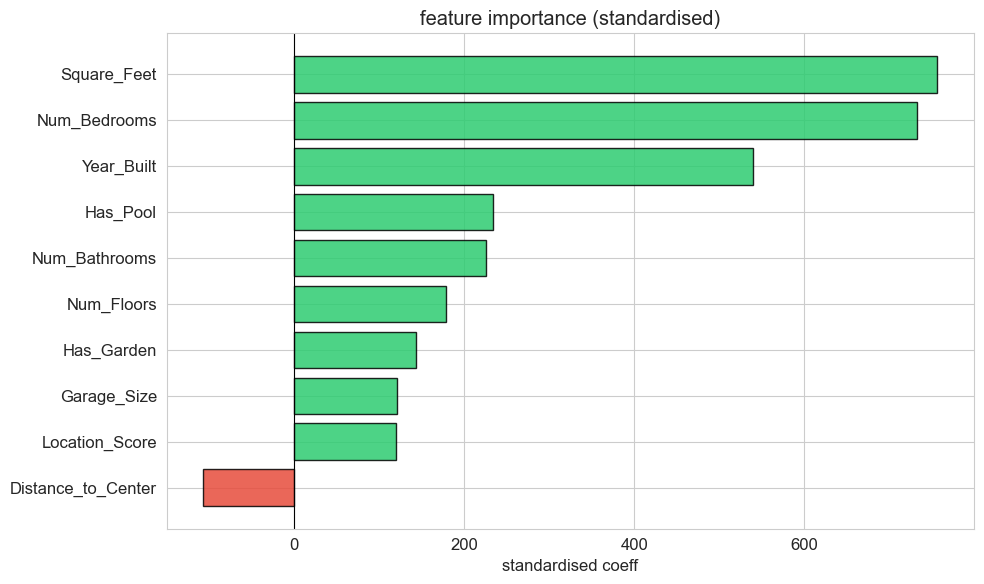


now we can compare coeff directly — bigger absolute value = more influence on price.


In [ ]:
# feature importance from standardised coeff
sc = pd.Series(bhat_s[1:], index=fcols).sort_values()

plt.figure(figsize=(10, 6))
clrs = ['#e74c3c' if v < 0 else '#2ecc71' for v in sc.values]
plt.barh(sc.index, sc.values, color=clrs, edgecolor='black', alpha=0.85)
plt.xlabel('standardised coeff')
plt.title('feature importance (standardised)')
plt.axvline(x=0, color='black', lw=0.8)
plt.tight_layout()
plt.show()

print("\nnow we can compare coeff directly thatis bigger absolute value = more influence on price.")

---
## Bonus 2 — polynomial regression

adding squared terms and interaction terms lets the model pick up nonlinear patterns.
for degree 2 with features [a, b] we get [a, b, a², ab, b²]. building this manually.

In [ ]:
def make_poly(x, deg=2):
    
    ##creates polynomial features up to given degree.
    ##for deg=2: original + squared + pairwise interactions.
    
    ns, nf = x.shape
    parts = [x]

    if deg >= 2:
        # squared terms
        parts.append(x ** 2)

        # interactions
        ints = []
        for i in range(nf):
            for j in range(i + 1, nf):
                ints.append((x[:, i] * x[:, j]).reshape(-1, 1))
        if ints:
            parts.append(np.hstack(ints))

    return np.hstack(parts)

In [ ]:
# build poly features from the standardised data (keeps things numerically stable)
xtr_p = make_poly(xtr_s, deg=2)
xte_p = make_poly(xte_s, deg=2)

print(f"original features: {xtr_s.shape[1]}")
print(f"poly features: {xtr_p.shape[1]}")

# add intercept
xtr_pf = np.hstack([np.ones((xtr_p.shape[0], 1)), xtr_p])
xte_pf = np.hstack([np.ones((xte_p.shape[0], 1)), xte_p])

original features: 10
poly features: 65


In [ ]:
# fit ols on poly features
xtx_p = xtr_pf.T @ xtr_pf
xtx_inv_p = np.linalg.inv(xtx_p)
xty_p = xtr_pf.T @ ytr

bhat_p = xtx_inv_p @ xty_p

print(f"total poly coeff: {len(bhat_p)}")

total poly coeff: 66


In [ ]:
# evaluate poly model
ytr_hat_p = xtr_pf @ bhat_p
yte_hat_p = xte_pf @ bhat_p

rss_tr_p = np.sum((ytr - ytr_hat_p) ** 2)
rss_te_p = np.sum((yte - yte_hat_p) ** 2)
mse_tr_p = rss_tr_p / len(ytr)
mse_te_p = rss_te_p / len(yte)
rmse_tr_p = np.sqrt(mse_tr_p)
rmse_te_p = np.sqrt(mse_te_p)
r2_tr_p = 1 - rss_tr_p / tss_tr
r2_te_p = 1 - rss_te_p / tss_te

print("=" * 55)
print("polynomial regression performance")
print("=" * 55)
print(f"{'metric':<25} {'train':>12} {'test':>12}")
print("-" * 55)
print(f"{'rss':<25} {rss_tr_p:>12.2f} {rss_te_p:>12.2f}")
print(f"{'mse':<25} {mse_tr_p:>12.2f} {mse_te_p:>12.2f}")
print(f"{'rmse':<25} {rmse_tr_p:>12.2f} {rmse_te_p:>12.2f}")
print(f"{'r-squared':<25} {r2_tr_p:>12.4f} {r2_te_p:>12.4f}")
print("=" * 55)

   polynomial regression performance
metric                           train         test
-------------------------------------------------------
rss                        71514259.49  17761200.92
mse                          178785.65    177612.01
rmse                            422.83       421.44
r-squared                       0.8817       0.8725


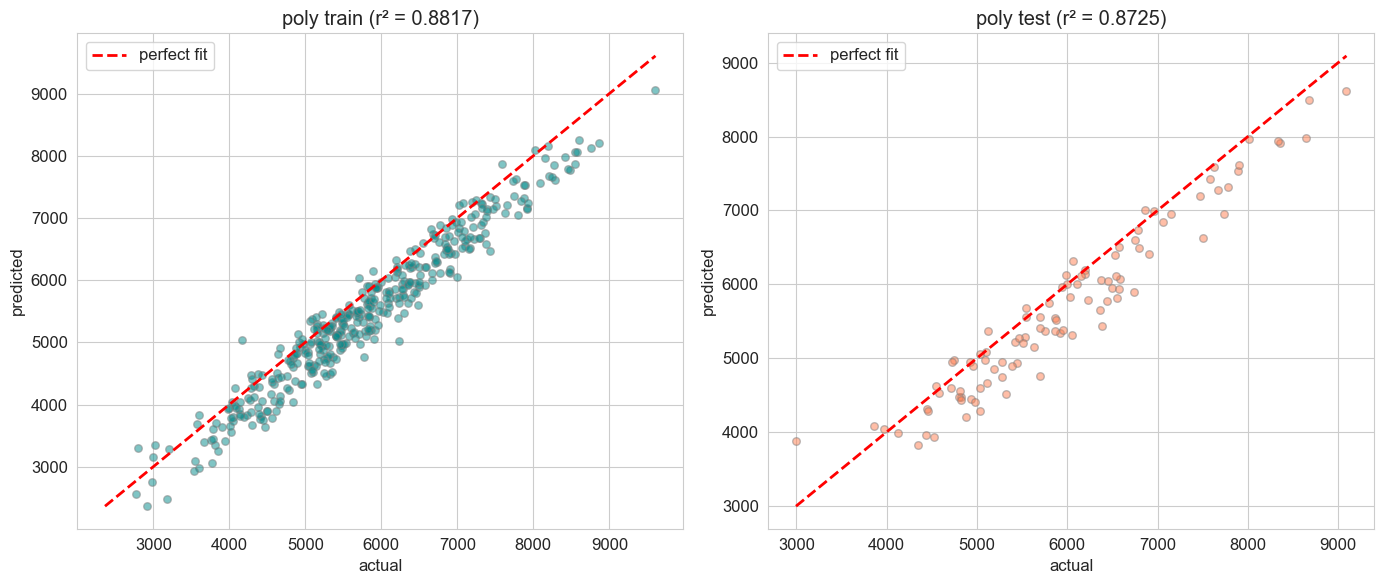

In [ ]:
# actual vs predicted in poly model
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].scatter(ytr, ytr_hat_p, alpha=0.5, color='darkcyan', edgecolors='gray', s=30)
lo, hi = min(ytr.min(), ytr_hat_p.min()), max(ytr.max(), ytr_hat_p.max())
axes[0].plot([lo, hi], [lo, hi], 'r--', lw=2, label='perfect fit')
axes[0].set_xlabel('actual')
axes[0].set_ylabel('predicted')
axes[0].set_title(f'poly train (r² = {r2_tr_p:.4f})')
axes[0].legend()

axes[1].scatter(yte, yte_hat_p, alpha=0.5, color='coral', edgecolors='gray', s=30)
lo, hi = min(yte.min(), yte_hat_p.min()), max(yte.max(), yte_hat_p.max())
axes[1].plot([lo, hi], [lo, hi], 'r--', lw=2, label='perfect fit')
axes[1].set_xlabel('actual')
axes[1].set_ylabel('predicted')
axes[1].set_title(f'poly test (r² = {r2_te_p:.4f})')
axes[1].legend()

plt.tight_layout()
plt.show()

## Comparing all three models

            all models — test set comparison
model                                 mse       rmse         r²
----------------------------------------------------------------------
basic ols                        56788.33     238.30     0.9592
ols + standardisation            56788.33     238.30     0.9592
polynomial (deg 2)              177612.01     421.44     0.8725


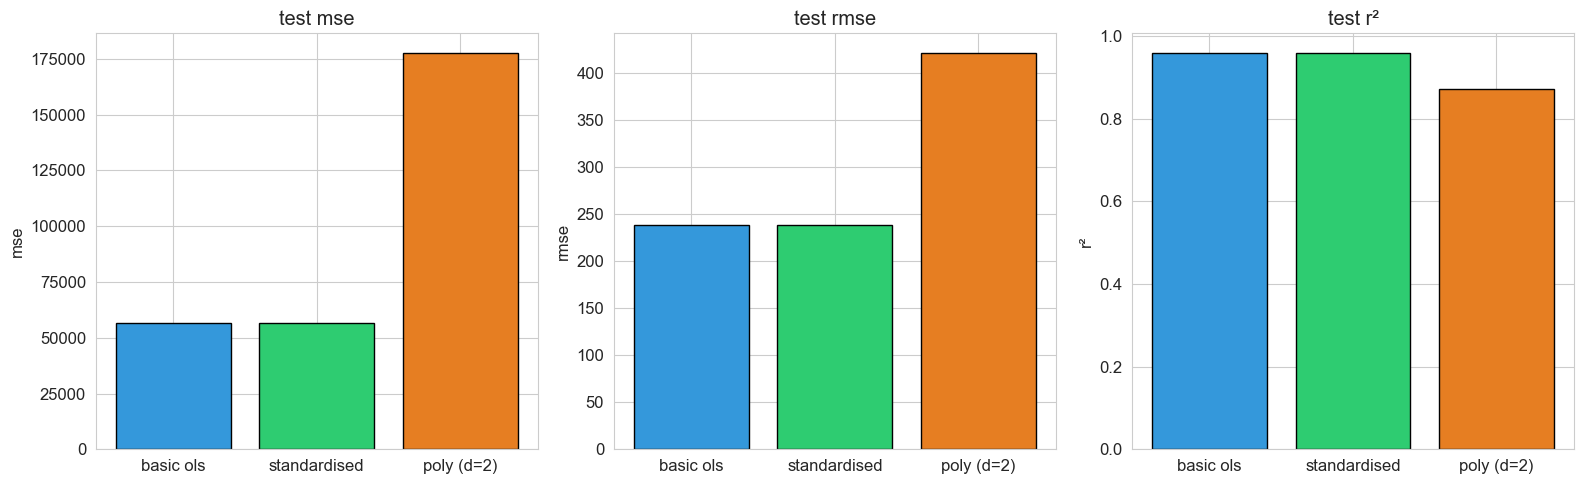

In [ ]:
# comparison table and bar charts
print("=" * 70)
print("all models — test set comparison")
print("=" * 70)
print(f"{'model':<30} {'mse':>10} {'rmse':>10} {'r²':>10}")
print("-" * 70)
print(f"{'basic ols':<30} {mse_te:>10.2f} {rmse_te:>10.2f} {r2_te:>10.4f}")
print(f"{'ols + standardisation':<30} {mse_te_s:>10.2f} {rmse_te_s:>10.2f} {r2_te_s:>10.4f}")
print(f"{'polynomial (deg 2)':<30} {mse_te_p:>10.2f} {rmse_te_p:>10.2f} {r2_te_p:>10.4f}")
print("=" * 70)

# bar charts
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
mdls = ['basic ols', 'standardised', 'poly (d=2)']
clrs = ['#3498db', '#2ecc71', '#e67e22']

axes[0].bar(mdls, [mse_te, mse_te_s, mse_te_p], color=clrs, edgecolor='black')
axes[0].set_title('test mse')
axes[0].set_ylabel('mse')

axes[1].bar(mdls, [rmse_te, rmse_te_s, rmse_te_p], color=clrs, edgecolor='black')
axes[1].set_title('test rmse')
axes[1].set_ylabel('rmse')

axes[2].bar(mdls, [r2_te, r2_te_s, r2_te_p], color=clrs, edgecolor='black')
axes[2].set_title('test r²')
axes[2].set_ylabel('r²')

plt.tight_layout()
plt.show()

## Takeaways

- Basic ols works well as a starting point. the matrix method gives us the best linear unbiased
  estimates (gauss-markov).

- Standardising doesnt change prediction accuracy (mse stays the same) but it lets us compare
  coeff properly. turns out bedrooms and pool are among the biggest price drivers.

- Polynomial regression adds nonlinear terms and interactions. if test r² goes up, there are
  real nonlinear patterns in the data. but if train r² is way higher than test r², we might
  be overfitting.